# **Discrete latent variables - Clustering and Generation**

A discrete latent variable answers a hidden categorical question: **which prototype or component generated this observation?** 

This notebook implements:

1. K-means and sequential K-means (hard assignments)
2. Image vector quantization (a learned discrete codebook)
3. Gaussian mixture EM (soft assignments, likelihood, and sampling)
4. The zero-variance connection between GMMs and K-means

## Setup

The notebook only needs NumPy and Matplotlib.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

SEED = 20
rng = np.random.default_rng(SEED)
plt.rcParams.update({"figure.figsize": (7, 4.5), "axes.grid": True})

def logsumexp(values, axis=-1, keepdims=False):
    """Stable log(sum(exp(values)))."""
    # Subtracting the largest value prevents overflow in exp(values).
    maximum = np.max(values, axis=axis, keepdims=True)
    result = maximum + np.log(np.sum(np.exp(values - maximum), axis=axis, keepdims=True))
    # Preserve the reduced axis only when the caller needs broadcasting.
    return result if keepdims else np.squeeze(result, axis=axis)

def squared_distances(X, centres):
    """Return all pairwise squared distances with shape (N, K)."""
    # Insert singleton axes so NumPy broadcasts every sample against every centre.
    return np.sum((X[:, None, :] - centres[None, :, :]) ** 2, axis=2)


## 1. K-means: a hard discrete latent variable

For observations $x_n$ and prototypes $\mu_k$, K-means alternates between a hard E-like step and an M-like step:

- assign each observation the code $z_n = \arg\min_k \lVert x_n-\mu_k\rVert^2$;
- replace every prototype with the mean of the observations carrying its code.

Its objective is $J=\sum_n \lVert x_n-\mu_{z_n}\rVert^2$. Each full iteration cannot increase $J$, although different initializations can reach different local optima.


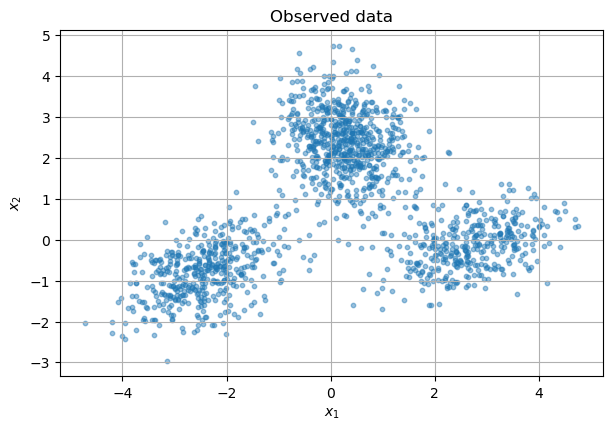

In [2]:
def make_gaussian_data(generator, n_per_component=500):
    """Sample observations from a known three-component Gaussian mixture."""
    # Each row is a two-dimensional component mean.
    means = np.array([[-2.5, -0.8], [0.3, 2.4], [2.7, -0.1]])
    # Full covariance matrices allow rotated, non-spherical clusters.
    covariances = np.array([
        [[0.55, 0.25], [0.25, 0.45]],
        [[0.45, -0.15], [-0.15, 0.70]],
        [[0.65, 0.20], [0.20, 0.35]],
    ])
    # Mixing weights define the prior probability of each latent component.
    weights = np.array([0.30, 0.45, 0.25])
    # Draw component counts jointly so their sum is exactly the requested total.
    counts = generator.multinomial(3 * n_per_component, weights)
    # Conditional on a component, draw samples from its Gaussian distribution.
    parts = [generator.multivariate_normal(mean, cov, count)
             for mean, cov, count in zip(means, covariances, counts)]
    return np.vstack(parts), means, covariances, weights

X, true_means, true_covariances, true_weights = make_gaussian_data(rng)
plt.scatter(X[:, 0], X[:, 1], s=10, alpha=0.45)
plt.title("Observed data")
plt.xlabel("$x_1$"); plt.ylabel("$x_2$");


Converged in 6 updates; final J = 1516.86


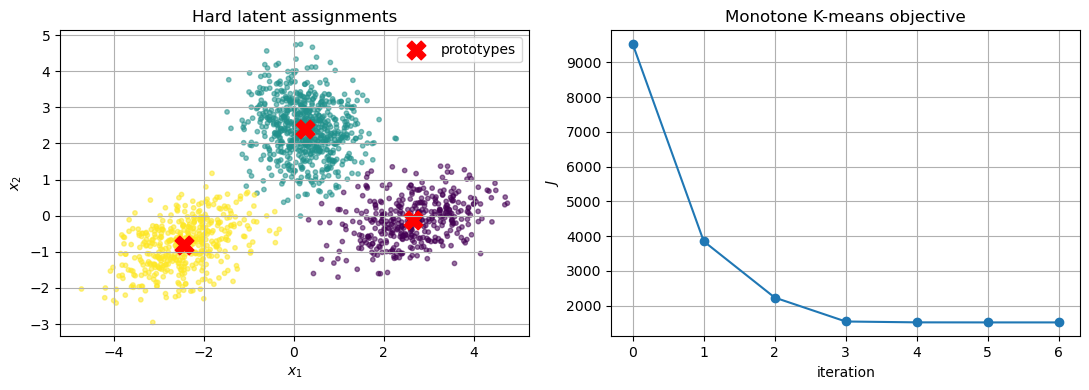

In [3]:
def kmeans(X, n_clusters, *, seed=0, max_iter=100, tolerance=1e-8):
    """Batch K-means with random-data-point initialization."""
    # Initialize cluster centres by randomly selecting data points.
    generator = np.random.default_rng(seed)
    centres = X[generator.choice(len(X), n_clusters, replace=False)].copy()

    # Keep track of the objective function value at each iteration.
    objective_history = []

    # max_iter is a safety guard; tolerance handles floating-point convergence.
    for _ in range(max_iter):
        # Compute the squared distances from each data point to each cluster centre.
        distances = squared_distances(X, centres)
        # E-like step: assign each point to its nearest centre.
        labels = np.argmin(distances, axis=1)

        # Sum only the distance selected by each point's hard assignment.
        objective = distances[np.arange(len(X)), labels].sum()
        objective_history.append(objective)

        new_centres = centres.copy()
        for k in range(n_clusters):
            members = X[labels == k]
            if len(members):
                # M-like step: the mean minimizes within-cluster squared error.
                new_centres[k] = members.mean(axis=0)
            else:
                # Revive an empty cluster at the currently worst represented point.
                new_centres[k] = X[np.argmax(np.min(distances, axis=1))]

        # Stop when the joint movement of all centres is negligible.
        if np.linalg.norm(new_centres - centres) <= tolerance:
            centres = new_centres
            break
        centres = new_centres

    # Refresh assignments and the objective so they match the final centres.
    distances = squared_distances(X, centres)
    labels = np.argmin(distances, axis=1)
    final_objective = distances[np.arange(len(X)), labels].sum()
    if not objective_history or final_objective < objective_history[-1] - tolerance:
        objective_history.append(final_objective)
    return centres, labels, np.asarray(objective_history)

km_centres, km_labels, km_objective = kmeans(X, 3, seed=SEED)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(X[:, 0], X[:, 1], c=km_labels, s=10, cmap="viridis", alpha=0.55)
axes[0].scatter(km_centres[:, 0], km_centres[:, 1], c="red", marker="X", s=180, label="prototypes")
axes[0].legend()
axes[0].set_xlabel("$x_1$")
axes[0].set_ylabel("$x_2$");
axes[0].set_title("Hard latent assignments");
axes[1].plot(km_objective, marker="o")
axes[1].set(title="Monotone K-means objective", xlabel="iteration", ylabel="$J$")
plt.tight_layout()

print(f"Converged in {len(km_objective) - 1} updates; final J = {km_objective[-1]:.2f}")


### Sequential K-means

Streaming data can update only its nearest prototype. After the $N_k$-th point assigned to component $k$, the exact running-mean update is $\mu_k \leftarrow \mu_k + (x_n-\mu_k)/N_k$. Multiple shuffled passes make this a simple online approximation to batch K-means.


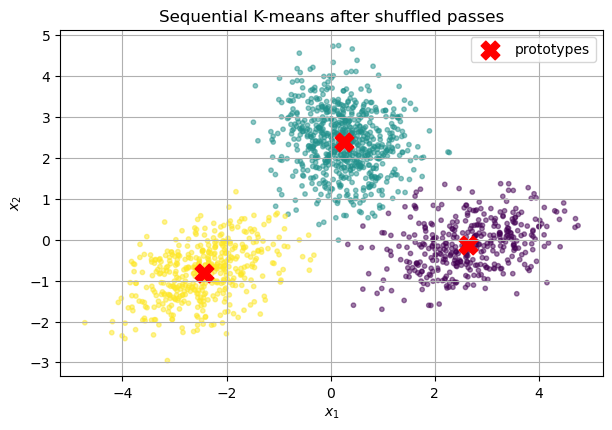

In [4]:
def sequential_kmeans(X, n_clusters, *, seed=0, passes=8):
    """Update one nearest centre at a time using a running mean."""
    generator = np.random.default_rng(seed)
    centres = X[generator.choice(len(X), n_clusters, replace=False)].copy()
    for _ in range(passes):
        # Reset per-pass counts, which determine the running-mean step size.
        counts = np.zeros(n_clusters, dtype=int)
        # Shuffling prevents the original data order from biasing the updates.
        for n in generator.permutation(len(X)):
            # Update only the prototype nearest to the current observation.
            k = np.argmin(np.sum((centres - X[n]) ** 2, axis=1))
            counts[k] += 1
            # This is the exact incremental formula for a sample mean.
            centres[k] += (X[n] - centres[k]) / counts[k]
    # Compute hard assignments once more using the final online centres.
    labels = np.argmin(squared_distances(X, centres), axis=1)
    return centres, labels

online_centres, online_labels = sequential_kmeans(X, 3, seed=SEED)
plt.scatter(X[:, 0], X[:, 1], c=online_labels, s=10, cmap="viridis", alpha=0.5)
plt.scatter(online_centres[:, 0], online_centres[:, 1], c="red", marker="X", s=180, label="prototypes")
plt.legend(); plt.xlabel("$x_1$"); plt.ylabel("$x_2$");
plt.title("Sequential K-means after shuffled passes");


## 2. Image vector quantization: learning a discrete codebook

Treat each RGB pixel as a 3D observation. The $K$ prototypes form a codebook, and the assignment map is a grid of discrete latent IDs. Replacing every pixel by its prototype compresses the image. Idealized storage changes from $24N$ bits to $24K + N\log_2 K$ bits (metadata and integer rounding ignored).

This toy case quantizes raw colors. VQ-VAEs use the same nearest-code operation in a learned feature space, where an encoder and decoder can preserve semantic and spatial information.


MSE: 0.00639
Idealized storage: 15552 -> 1968 bytes (7.9x smaller)


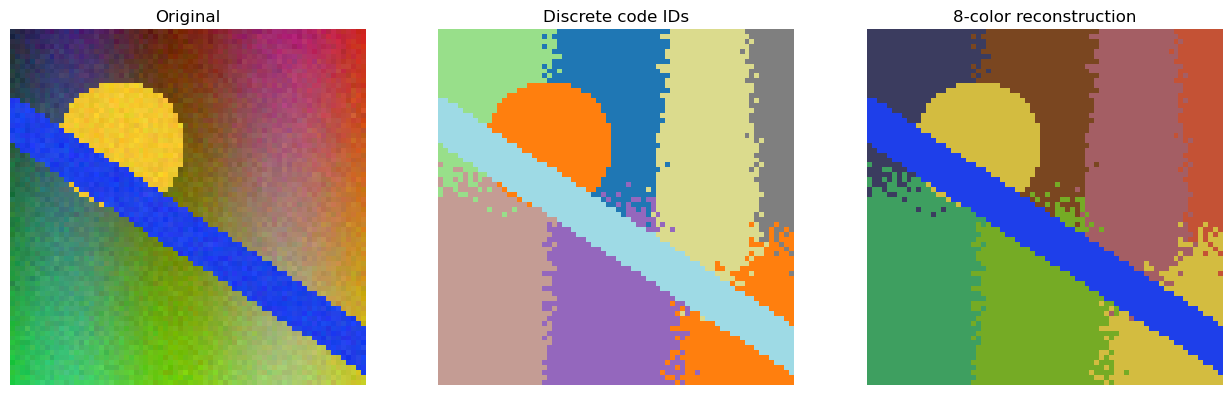

In [5]:
def make_toy_image(size=72):
    """Create a reproducible RGB image with smooth and sharp structure."""
    # mgrid creates a dense multi-dimensional "meshgrid".
    y, x = np.mgrid[0:size, 0:size]

    image = np.zeros((size, size, 3), dtype=float)
    # Build a different smooth spatial pattern in each color channel.
    image[..., 0] = 0.15 + 0.65 * x / (size - 1)
    image[..., 1] = 0.15 + 0.65 * y / (size - 1)
    image[..., 2] = 0.25 + 0.20 * np.sin(x / 7)

    # Add a disk and a stripe to the image.
    disk = (x - 22) ** 2 + (y - 23) ** 2 < 13 ** 2
    stripe = np.abs(y - (0.65 * x + 18)) < 5

    image[disk] = [0.95, 0.78, 0.18]
    image[stripe] = [0.12, 0.25, 0.92]

    # Small pixel noise makes color quantization non-trivial.
    noise = np.random.default_rng(SEED).normal(0, 0.025, image.shape)
    return np.clip(image + noise, 0, 1)

image = make_toy_image()
# Flatten the spatial dimensions: K-means treats each RGB pixel as a 3D vector.
pixels = image.reshape(-1, 3)
codebook_size = 8
# Run K-means on the pixels to get a codebook and discrete token IDs.
codebook, token_ids, vq_objective = kmeans(pixels, codebook_size, seed=SEED, max_iter=80)

# Visualize the codebook and the reconstruction.
# Decode every discrete token by looking up its RGB codebook vector.
reconstruction = codebook[token_ids].reshape(image.shape)
token_map = token_ids.reshape(image.shape[:2])

n_pixels = len(pixels)
# Raw RGB uses 24 bits per pixel. Quantization stores the codebook plus token IDs.
raw_bits = 24 * n_pixels
quantized_bits_ideal = 24 * codebook_size + n_pixels * np.log2(codebook_size)

mse = np.mean((image - reconstruction) ** 2)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(image); axes[0].set_title("Original")
axes[1].imshow(token_map, cmap="tab20"); axes[1].set_title("Discrete code IDs")
axes[2].imshow(reconstruction); axes[2].set_title(f"{codebook_size}-color reconstruction")
for ax in axes: ax.axis("off")
plt.tight_layout()
print(f"MSE: {mse:.5f}")
print(f"Idealized storage: {raw_bits / 8:.0f} -> {quantized_bits_ideal / 8:.0f} bytes "
      f"({raw_bits / quantized_bits_ideal:.1f}x smaller)")


## 3. Gaussian mixtures and EM

A Gaussian mixture is a generative model:

1. sample a latent component $z \sim \mathrm{Categorical}(\pi)$;
2. sample $x \mid z=k \sim \mathcal N(\mu_k, \Sigma_k)$.

Marginalizing the hidden component gives $p(x)=\sum_k \pi_k\mathcal N(x\mid\mu_k,\Sigma_k)$. The E-step computes responsibilities $\gamma_{nk}=p(z_n=k\mid x_n)$; the M-step uses them as fractional counts to update $\pi_k$, $\mu_k$, and $\Sigma_k$.

The implementation below works in log space for numerical stability and adds `reg_covar` to every covariance. That small regularizer prevents a component from collapsing onto one data point with variance approaching zero.


In [6]:
def gaussian_log_densities(X, means, covariances):
    """Compute log N(x_n | mu_k, Sigma_k) for every sample and component."""
    # X has shape (N, D)
    n_features = X.shape[1]
    # The result has shape (N, K), with one column per component.
    result = np.empty((len(X), len(means)))
    # Normalization term D * log(2*pi), shared by all Gaussian components.
    constant = n_features * np.log(2 * np.pi)

    for k, (mean, covariance) in enumerate(zip(means, covariances)):
        # Sigma = L L^T. Cholesky is more stable than computing inv(Sigma).
        chol = np.linalg.cholesky(covariance)
        # Solve L y = (x - mu) to obtain the whitened observations.
        whitened = np.linalg.solve(chol, (X - mean).T).T
        # ||y||^2 is the squared Mahalanobis distance.
        mahalanobis = np.sum(whitened ** 2, axis=1)
        # Since det(Sigma) = det(L)^2, log|Sigma| = 2 sum_i log L_ii.
        log_determinant = 2 * np.log(np.diag(chol)).sum()
        # Gaussian log density: -1/2 [D log(2*pi) + log|Sigma| + distance].
        result[:, k] = -0.5 * (constant + log_determinant + mahalanobis)

    return result

def gmm_e_step(X, weights, means, covariances):
    """E-step: compute posterior responsibilities and log likelihood."""
    # log p(x_n, z_n=k) = log pi_k + log N(x_n | mu_k, Sigma_k).
    # Clipping prevents log(0) if a weight becomes numerically zero.
    log_joint = np.log(np.clip(weights, 1e-15, None)) + gaussian_log_densities(X, means, covariances)
    # log p(x_n) = log sum_k p(x_n, z_n=k), evaluated stably.
    log_marginal = logsumexp(log_joint, axis=1)
    # gamma_nk = p(z_n=k | x_n): each row sums to one.
    responsibilities = np.exp(log_joint - log_marginal[:, None])
    # For i.i.d. data, log p(X) is the sum of the individual log probabilities.
    return responsibilities, log_marginal.sum()

def gmm_em(X, n_components, *, seed=0, max_iter=200, tolerance=1e-6, reg_covar=1e-5):
    """Estimate a Gaussian mixture model with the EM algorithm."""
    n_samples, n_features = X.shape

    # Initialize component means and assignments with K-means.
    means, labels, _ = kmeans(X, n_components, seed=seed)
    # Initial cluster frequencies become the mixing coefficients pi_k.
    # Clipping assigns at least one count even to an empty cluster.
    weights = np.bincount(labels, minlength=n_components).astype(float)
    weights = np.clip(weights, 1.0, None) / np.clip(weights, 1.0, None).sum()
    # Initialize every component with the global data covariance.
    # Adding reg_covar to the diagonal keeps it positive definite and invertible.
    global_covariance = np.cov(X, rowvar=False) + reg_covar * np.eye(n_features)
    covariances = np.stack([global_covariance.copy() for _ in range(n_components)])
    # Store the log likelihood to monitor convergence and monotonicity.
    history = []

    for _ in range(max_iter):
        # E-step: infer the distribution of the latent component z_n.
        responsibilities, log_likelihood = gmm_e_step(X, weights, means, covariances)
        history.append(log_likelihood)

        # N_k is the effective (fractional) number of samples in component k.
        # The epsilon prevents division by zero for nearly empty components.
        effective_counts = responsibilities.sum(axis=0) + 1e-12

        # M-step: update pi_k and the means using gamma_nk-weighted statistics.
        weights = effective_counts / n_samples
        # einsum contracts the sample axis n and keeps component k and feature d.
        means = np.einsum("nk,nd->kd", responsibilities, X) / effective_counts[:, None]

        for k in range(n_components):
            # Deviations from the updated mean of component k.
            centred = X - means[k]
            # Weighted covariance: sum_n gamma_nk (x_n-mu_k)(x_n-mu_k)^T / N_k.
            covariances[k] = np.einsum("n,ni,nj->ij", responsibilities[:, k], centred, centred) / effective_counts[k]
            # Impose a variance floor to prevent component collapse.
            # This flat stride selects exactly the diagonal entries of the matrix.
            covariances[k].flat[:: n_features + 1] += reg_covar

        # Stop when the log-likelihood improvement becomes negligible.
        if len(history) > 1 and history[-1] - history[-2] < tolerance:
            break

    # Recompute the E-step so responsibilities and likelihood match the final parameters.
    responsibilities, final_log_likelihood = gmm_e_step(X, weights, means, covariances)
    if not history or final_log_likelihood > history[-1] + 1e-10:
        history.append(final_log_likelihood)

    return weights, means, covariances, responsibilities, np.asarray(history)

# Fit a three-component GMM to the synthetic dataset X.
gmm_weights, gmm_means, gmm_covariances, responsibilities, gmm_history = gmm_em(
    X, 3, seed=SEED, reg_covar=1e-4
)

print("Mixing coefficients:", np.round(gmm_weights, 3))
print(f"EM iterations: {len(gmm_history) - 1}; final log likelihood: {gmm_history[-1]:.2f}")


Mixing coefficients: [0.248 0.451 0.301]
EM iterations: 16; final log likelihood: -4695.62


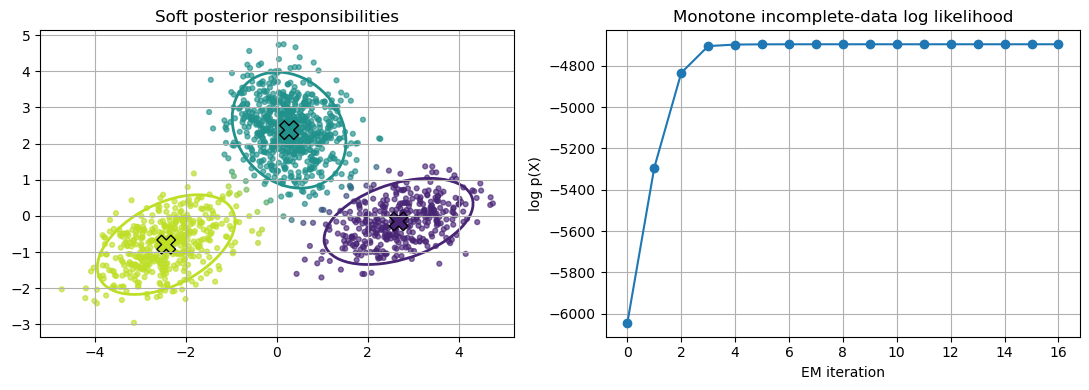

In [7]:
def add_covariance_ellipse(ax, mean, covariance, color, n_std=2.0):
    """Plot a principal-axis ellipse for a 2D Gaussian covariance."""
    # For a symmetric covariance matrix, eigenvectors give the principal axes.
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)
    # Sort from the largest to the smallest variance direction.
    order = eigenvalues.argsort()[::-1]
    eigenvalues, eigenvectors = eigenvalues[order], eigenvectors[:, order]
    # The first eigenvector determines the ellipse rotation in the plot.
    angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
    # Axis lengths are proportional to the standard deviations sqrt(lambda).
    width, height = 2 * n_std * np.sqrt(eigenvalues)
    ax.add_patch(Ellipse(mean, width, height, angle=angle, fill=False, lw=2, color=color))

colors = plt.cm.viridis(np.linspace(0.1, 0.9, 3))
# Blend component colors using posterior responsibilities as convex weights.
soft_colors = np.sum(responsibilities[:, :, None] * colors[None, :, :], axis=1)
# Guard against tiny floating-point excursions outside the valid RGBA range.
soft_colors = np.clip(soft_colors, 0.0, 1.0)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(X[:, 0], X[:, 1], c=soft_colors, s=12, alpha=0.65)
for mean, covariance, color in zip(gmm_means, gmm_covariances, colors):
    add_covariance_ellipse(axes[0], mean, covariance, color)
axes[0].scatter(gmm_means[:, 0], gmm_means[:, 1], c=colors, edgecolor="black", marker="X", s=180)
axes[0].set_title("Soft posterior responsibilities")
axes[1].plot(gmm_history, marker="o")
axes[1].set(title="Monotone incomplete-data log likelihood", xlabel="EM iteration", ylabel="log p(X)")
plt.tight_layout()


### The complete-data viewpoint

If component indicators were observed, the log likelihood would separate into easy terms:

$$\log p(X,Z\mid\theta)=\sum_{n,k}z_{nk}[\log\pi_k+\log\mathcal N(x_n\mid\mu_k,\Sigma_k)].$$

EM substitutes the posterior expectation $\mathbb E[z_{nk}]=\gamma_{nk}$. In general, its E-step forms $Q(\theta,\theta^{old})=\mathbb E_{p(Z\mid X,\theta^{old})}[\log p(X,Z\mid\theta)]$, and its M-step maximizes this function. The soft counts above are exactly that expectation.


### Ancestral sampling: use the model generatively

Once fitted, a mixture is more than a clustering algorithm. Sampling a component from $\pi$ and then an observation from its conditional density produces new data. The sampled component ID is the discrete latent variable.


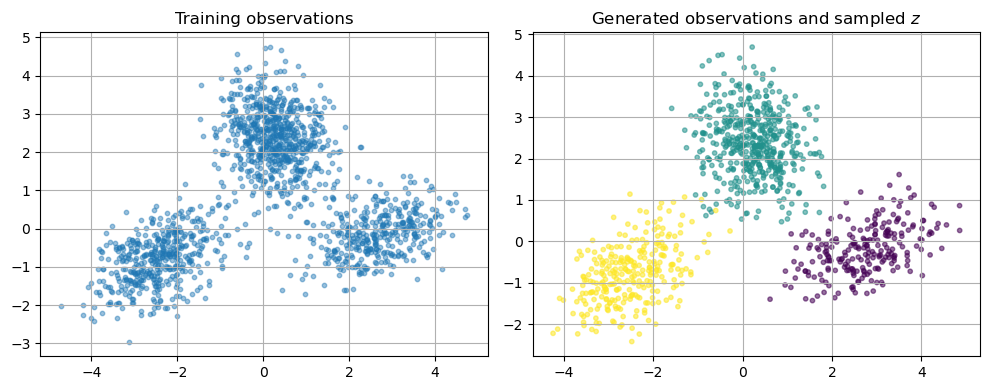

In [8]:
def sample_gmm(generator, n_samples, weights, means, covariances):
    """Generate observations by ancestral sampling from a fitted GMM."""
    # First sample the discrete latent component z from Categorical(weights).
    latent_ids = generator.choice(len(weights), size=n_samples, p=weights)
    # Allocate output once, then fill it component by component.
    samples = np.empty((n_samples, means.shape[1]))
    for k in range(len(weights)):
        # Select the output rows whose sampled latent variable equals k.
        mask = latent_ids == k
        # Then sample x conditionally from N(mean_k, covariance_k).
        samples[mask] = generator.multivariate_normal(means[k], covariances[k], mask.sum())
    return samples, latent_ids

generated_X, generated_z = sample_gmm(rng, 1000, gmm_weights, gmm_means, gmm_covariances)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(X[:, 0], X[:, 1], s=10, alpha=0.45); axes[0].set_title("Training observations")
axes[1].scatter(generated_X[:, 0], generated_X[:, 1], c=generated_z, cmap="viridis", s=10, alpha=0.55)
axes[1].set_title("Generated observations and sampled $z$")
plt.tight_layout()


## 4. K-means as the zero-variance limit of a GMM

For shared isotropic covariance $\Sigma_k=\epsilon I$, responsibilities are a softmax over negative squared distances scaled by $1/(2\epsilon)$. As $\epsilon \to 0$, the nearest mean receives probability one and EM's soft assignment becomes K-means' hard assignment.


In [9]:
def isotropic_responsibilities(X, means, variance, weights=None):
    """Compute GMM responsibilities for shared covariance variance * I."""
    if weights is None:
        # Equal priors isolate the effect of distance and variance.
        weights = np.full(len(means), 1 / len(means))
    # Constants shared by all components cancel in the posterior ratio.
    # The remaining log score is log pi_k - ||x-mu_k||^2 / (2*variance).
    logits = np.log(weights) - squared_distances(X, means) / (2 * variance)
    # Normalize in log space; smaller variance makes the softmax approach argmin.
    return np.exp(logits - logsumexp(logits, axis=1, keepdims=True))

variances = [2.0, 0.5, 0.1, 0.02]
print("variance | mean max responsibility | disagreement with nearest mean")
nearest = np.argmin(squared_distances(X, km_centres), axis=1)
for variance in variances:
    soft = isotropic_responsibilities(X, km_centres, variance)
    disagreement = np.mean(np.argmax(soft, axis=1) != nearest)
    print(f"{variance:8.2f} | {soft.max(axis=1).mean():23.4f} | {disagreement:29.4f}")

# A single point near a boundary makes the sharpening especially visible.
boundary_point = ((km_centres[0] + km_centres[1]) / 2 + np.array([0.08, -0.03]))[None, :]
for variance in variances:
    print(f"epsilon={variance:>4}:", np.round(isotropic_responsibilities(boundary_point, km_centres, variance)[0], 4))


variance | mean max responsibility | disagreement with nearest mean
    2.00 |                  0.9178 |                        0.0000
    0.50 |                  0.9912 |                        0.0000
    0.10 |                  0.9985 |                        0.0000
    0.02 |                  0.9998 |                        0.0000
epsilon= 2.0: [0.5289 0.4628 0.0083]
epsilon= 0.5: [0.6304 0.3696 0.    ]
epsilon= 0.1: [0.9352 0.0648 0.    ]
epsilon=0.02: [1. 0. 0.]


### Why covariance regularization matters

A Gaussian density evaluated at its own mean scales like $\sigma^{-D}$. A component can therefore collapse onto one training point and drive maximum likelihood toward infinity. The calculation below shows the divergence in one dimension. `reg_covar` imposes a variance floor in our EM implementation; Bayesian parameter priors are a more principled alternative.


<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
/var/folders/q2/c_0y_0yj6nqg6pjrqy90sshc0000gn/T/ipykernel_81440/447899.py:8: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel("standard deviation $\sigma$ (shrinking to the right)")


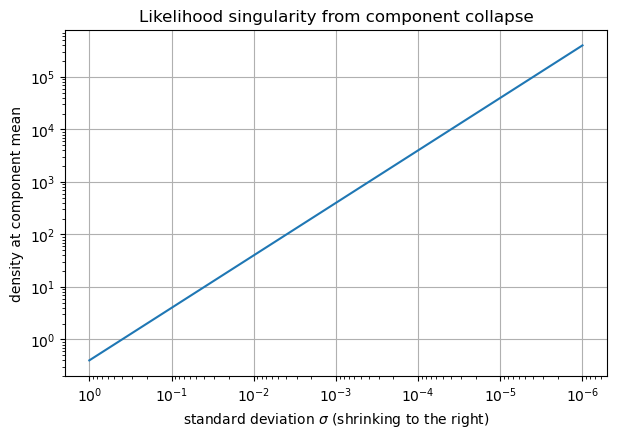

In [10]:
# Evaluate progressively smaller standard deviations on a logarithmic grid.
sigmas = np.logspace(0, -6, 120)
# At its own mean, a 1D Gaussian density is 1 / (sqrt(2*pi) * sigma).
# It therefore diverges as sigma approaches zero, creating a GMM singularity.
density_at_mean = 1 / (np.sqrt(2 * np.pi) * sigmas)
plt.loglog(sigmas, density_at_mean)
plt.gca().invert_xaxis()
plt.xlabel("standard deviation $\sigma$ (shrinking to the right)")
plt.ylabel("density at component mean")
plt.title("Likelihood singularity from component collapse");
